### Projet : Prédiction de la qualité de l'air dans les villes marocaines
# Étape 3 : Construction et évaluation des modèles
On va :
1. Charger le dataset propre (issu de l'étape 2)
2. Séparer les données en train/test (80/20)
3. Entraîner deux modèles : Régression Linéaire et Random Forest
4. Évaluer et comparer les performances (MAE, RMSE, R²)
5. Visualiser les résultats et l'importance des features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## 1. Chargement du dataset propre

In [3]:
# Charger le dataset préparé à l'étape 2
df = pd.read_csv("Data/data_clean.csv")

print(f"Lignes   : {len(df)}")
print(f"Colonnes : {len(df.columns)}")
print()

FEATURES = [col for col in df.columns if col not in ['pm2_5', 'ville']]
X = df[FEATURES]
y = df['pm2_5']

print(f"Features ({len(FEATURES)}) :")
for f in FEATURES:
    print(f"  - {f}")
print()
print(f"Target : pm2_5  |  min={y.min():.2f}, max={y.max():.2f}, moyenne={y.mean():.2f}")

Lignes   : 212
Colonnes : 22

Features (20) :
  - temperature
  - temp_ressentie
  - temp_min
  - temp_max
  - humidite
  - pression
  - vent_vitesse
  - vent_direction
  - nuages
  - visibilite
  - pm10
  - no2
  - o3
  - co
  - so2
  - heure
  - jour_semaine
  - jour_mois
  - ville_encoded
  - meteo_encoded

Target : pm2_5  |  min=0.68, max=6.97, moyenne=2.91


## 2. Division Train / Test (80% / 20%)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Division Train / Test :")
print(f"  Train : {len(X_train)} lignes ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test  : {len(X_test)} lignes  ({len(X_test)/len(X)*100:.0f}%)")

Division Train / Test :
  Train : 169 lignes (80%)
  Test  : 43 lignes  (20%)


## 3. Modèle 1 — Régression Linéaire

In [5]:
# Créer et entraîner le modèle
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("RÉGRESSION LINÉAIRE — Résultats sur le set de test :")
print("=" * 45)
print(f"  MAE  (Erreur absolue moyenne)  : {mae_lr:.4f} µg/m³")
print(f"  RMSE (Racine erreur quadratique): {rmse_lr:.4f} µg/m³")
print(f"  R²   (Coefficient de détermination): {r2_lr:.4f}")
print()
print("Interprétation :")
print(f"  Le modèle explique {r2_lr*100:.1f}% de la variance de PM2.5")
print(f"  En moyenne, il se trompe de ±{mae_lr:.2f} µg/m³")

RÉGRESSION LINÉAIRE — Résultats sur le set de test :
  MAE  (Erreur absolue moyenne)  : 0.4935 µg/m³
  RMSE (Racine erreur quadratique): 0.6188 µg/m³
  R²   (Coefficient de détermination): 0.8140

Interprétation :
  Le modèle explique 81.4% de la variance de PM2.5
  En moyenne, il se trompe de ±0.49 µg/m³


## 4. Modèle 2 — Random Forest

In [6]:

rf = RandomForestRegressor(
    n_estimators=100,   
    max_depth=10,       
    random_state=42
)
rf.fit(X_train, y_train)

# Prédictions sur le set de test
y_pred_rf = rf.predict(X_test)

# Calculer les métriques
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST — Résultats sur le set de test :")
print("=" * 45)
print(f"  MAE  (Erreur absolue moyenne)   : {mae_rf:.4f} µg/m³")
print(f"  RMSE (Racine erreur quadratique): {rmse_rf:.4f} µg/m³")
print(f"  R²   (Coefficient de détermination): {r2_rf:.4f}")
print()
print("Interprétation :")
print(f"  Le modèle explique {r2_rf*100:.1f}% de la variance de PM2.5")
print(f"  En moyenne, il se trompe de ±{mae_rf:.2f} µg/m³")

RANDOM FOREST — Résultats sur le set de test :
  MAE  (Erreur absolue moyenne)   : 0.3293 µg/m³
  RMSE (Racine erreur quadratique): 0.4630 µg/m³
  R²   (Coefficient de détermination): 0.8959

Interprétation :
  Le modèle explique 89.6% de la variance de PM2.5
  En moyenne, il se trompe de ±0.33 µg/m³


## 5. Comparaison des deux modèles

In [7]:
# Tableau de comparaison
resultats = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest'],
    'MAE':    [round(mae_lr, 4),  round(mae_rf, 4)],
    'RMSE':   [round(rmse_lr, 4), round(rmse_rf, 4)],
    'R²':     [round(r2_lr, 4),   round(r2_rf, 4)]
})

print("TABLEAU COMPARATIF")
print("=" * 50)
print(resultats.to_string(index=False))
print()

meilleur = "Random Forest" if r2_rf > r2_lr else "Régression Linéaire"
print(f"=> Meilleur modèle : {meilleur}")

TABLEAU COMPARATIF
             Modèle    MAE   RMSE     R²
Régression Linéaire 0.4935 0.6188 0.8140
      Random Forest 0.3293 0.4630 0.8959

=> Meilleur modèle : Random Forest


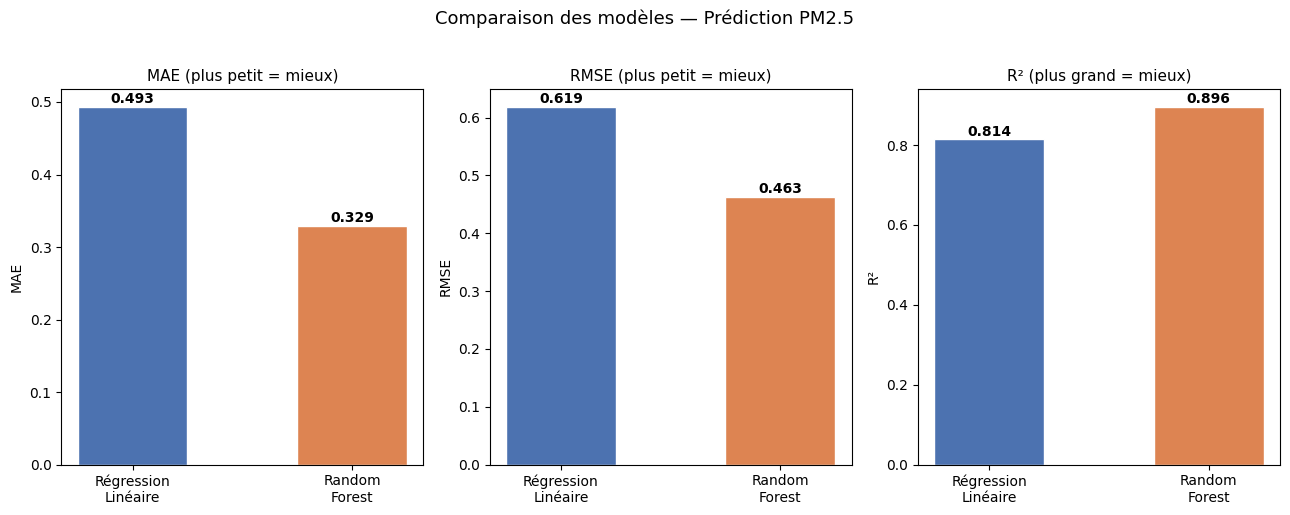

Graphique sauvegardé : comparaison_modeles.png


In [8]:
# Graphique comparatif des métriques
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
modeles = ['Régression\nLinéaire', 'Random\nForest']
couleurs = ['#4C72B0', '#DD8452']

for ax, metrique, valeurs, titre in zip(
    axes,
    ['MAE', 'RMSE', 'R²'],
    [[mae_lr, mae_rf], [rmse_lr, rmse_rf], [r2_lr, r2_rf]],
    ['MAE (plus petit = mieux)', 'RMSE (plus petit = mieux)', 'R² (plus grand = mieux)']
):
    bars = ax.bar(modeles, valeurs, color=couleurs, edgecolor='white', width=0.5)
    ax.set_title(titre, fontsize=11)
    ax.set_ylabel(metrique)
    for bar, val in zip(bars, valeurs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparaison des modèles — Prédiction PM2.5', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : comparaison_modeles.png")

## 6. Visualisation des prédictions vs valeurs réelles

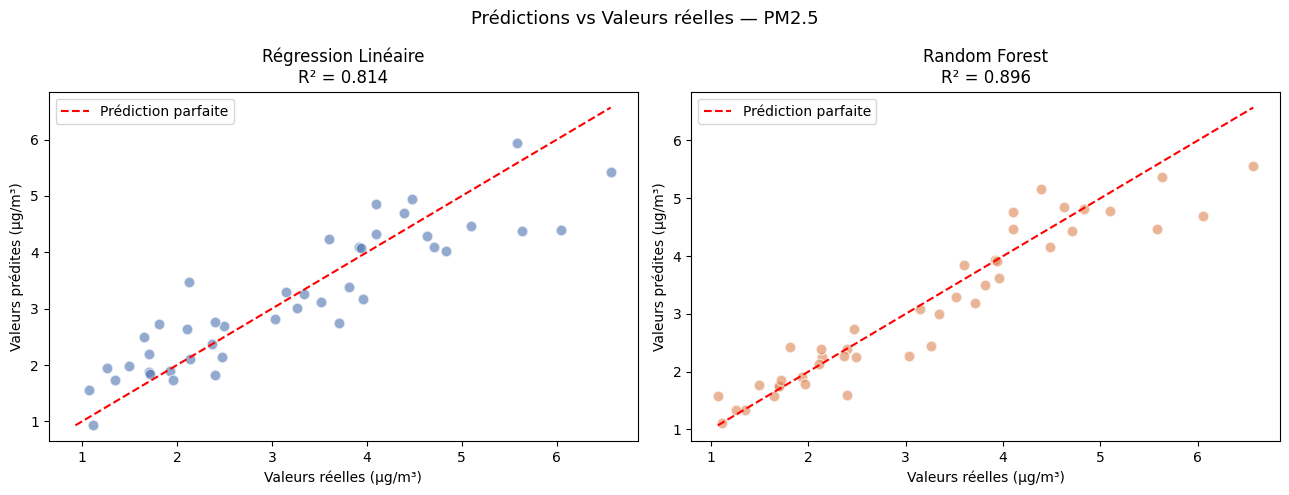

Graphique sauvegardé : predictions_vs_reel.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, titre, couleur in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Régression Linéaire', 'Random Forest'],
    ['#4C72B0', '#DD8452']
):
    ax.scatter(y_test, y_pred, color=couleur, alpha=0.6, edgecolors='white', s=60)
    
    # Ligne de référence parfaite (y = x)
    min_val = min(y_test.min(), min(y_pred))
    max_val = max(y_test.max(), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Prédiction parfaite')
    
    ax.set_title(f'{titre}\nR² = {r2_score(y_test, y_pred):.3f}', fontsize=12)
    ax.set_xlabel('Valeurs réelles (µg/m³)')
    ax.set_ylabel('Valeurs prédites (µg/m³)')
    ax.legend()

plt.suptitle('Prédictions vs Valeurs réelles — PM2.5', fontsize=13)
plt.tight_layout()
plt.savefig('predictions_vs_reel.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : predictions_vs_reel.png")

## 7. Importance des features (Random Forest)


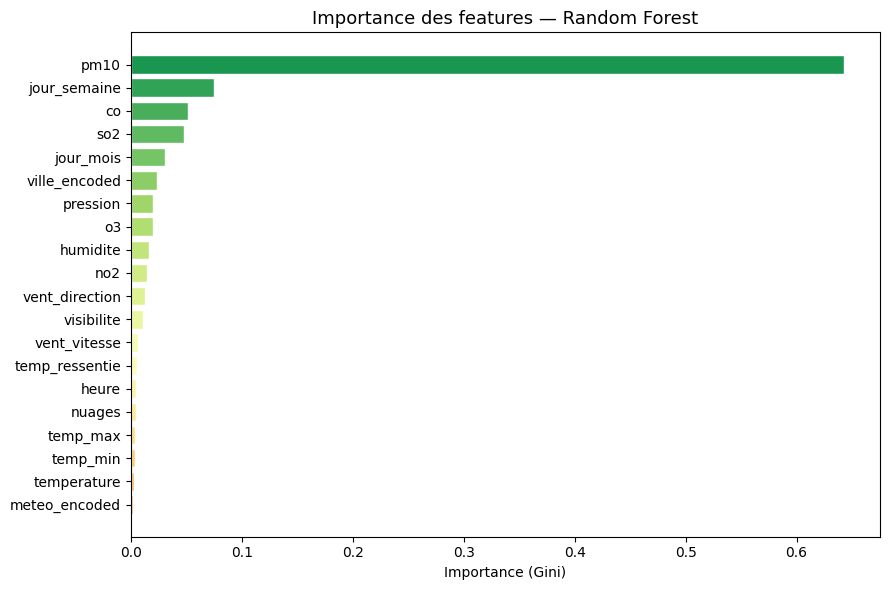

Top 5 features les plus importantes :
  1. pm10: 0.6431
  2. jour_semaine: 0.0749
  3. co: 0.0517
  4. so2: 0.0482
  5. jour_mois: 0.0304


In [10]:
# Extraire l'importance des features
importance = pd.Series(rf.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance)))
bars = plt.barh(importance.index, importance.values, color=colors, edgecolor='white')
plt.title('Importance des features — Random Forest', fontsize=13)
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('importance_features.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 features les plus importantes :")
for i, (feat, val) in enumerate(importance.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat}: {val:.4f}")

## 8. Analyse des erreurs

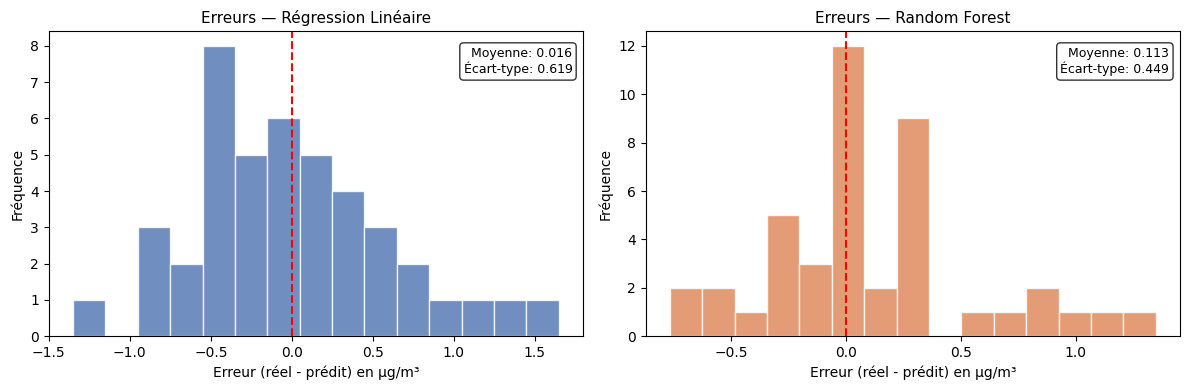

Graphique sauvegardé : distribution_erreurs.png


In [11]:
# Distribution des erreurs de prédiction
erreurs_lr = y_test.values - y_pred_lr
erreurs_rf = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, erreurs, titre, couleur in zip(
    axes,
    [erreurs_lr, erreurs_rf],
    ['Régression Linéaire', 'Random Forest'],
    ['#4C72B0', '#DD8452']
):
    ax.hist(erreurs, bins=15, color=couleur, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Erreurs — {titre}', fontsize=11)
    ax.set_xlabel('Erreur (réel - prédit) en µg/m³')
    ax.set_ylabel('Fréquence')
    ax.text(0.98, 0.95, f'Moyenne: {erreurs.mean():.3f}\nÉcart-type: {erreurs.std():.3f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.savefig('distribution_erreurs.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : distribution_erreurs.png")

## 9. Résumé final

In [12]:
print("=" * 55)
print("   RÉSUMÉ ÉTAPE 3 — MODÉLISATION")
print("=" * 55)
print()
print(f"  Données d'entraînement : {len(X_train)} lignes")
print(f"  Données de test        : {len(X_test)} lignes")
print()
print("  RÉGRESSION LINÉAIRE :")
print(f"    MAE  = {mae_lr:.4f} µg/m³")
print(f"    RMSE = {rmse_lr:.4f} µg/m³")
print(f"    R²   = {r2_lr:.4f}")
print()
print("  RANDOM FOREST :")
print(f"    MAE  = {mae_rf:.4f} µg/m³")
print(f"    RMSE = {rmse_rf:.4f} µg/m³")
print(f"    R²   = {r2_rf:.4f}")
print()
meilleur = "Random Forest" if r2_rf > r2_lr else "Régression Linéaire"
print(f"  => Meilleur modèle : {meilleur}")
print()
print("  Fichiers générés :")
print("    - comparaison_modeles.png")
print("    - predictions_vs_reel.png")
print("    - importance_features.png")
print("    - distribution_erreurs.png")
print("=" * 55)

   RÉSUMÉ ÉTAPE 3 — MODÉLISATION

  Données d'entraînement : 169 lignes
  Données de test        : 43 lignes

  RÉGRESSION LINÉAIRE :
    MAE  = 0.4935 µg/m³
    RMSE = 0.6188 µg/m³
    R²   = 0.8140

  RANDOM FOREST :
    MAE  = 0.3293 µg/m³
    RMSE = 0.4630 µg/m³
    R²   = 0.8959

  => Meilleur modèle : Random Forest

  Fichiers générés :
    - comparaison_modeles.png
    - predictions_vs_reel.png
    - importance_features.png
    - distribution_erreurs.png
